# RavenStack SaaS — Does Support Predict Churn?

**Author:** Namık Akman  
**Question:** In notebook 2 we found that *support* was the most-cited reason given by customers who churned at the 12–18 month renewal moment. This notebook asks whether the data actually backs that up.

**Hypothesis from notebook 2:**

> *Customers who file many support tickets in months 9–12 will churn at higher rates in months 13–18.*

If true, support volume in the pre-renewal window is a leading indicator — and customer success outreach should be triggered by ticket activity.  
If false, the "support" reason cited at churn is likely a euphemism for something else, and ticket dashboards aren't the right early-warning system.

## 1. Setup and build the per-account support summary

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path(r'C:\Users\Lenovo\OneDrive\Creative\Churn Study\data')

BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE = '#2F9BFF', '#19C37D', '#FF6500'
BG_DARK, FG_LIGHT = '#0F1419', '#E6EDF3'
plt.rcParams.update({
    'figure.facecolor': BG_DARK, 'axes.facecolor': BG_DARK, 'savefig.facecolor': BG_DARK,
    'axes.edgecolor': FG_LIGHT, 'axes.labelcolor': FG_LIGHT,
    'xtick.color': FG_LIGHT, 'ytick.color': FG_LIGHT, 'text.color': FG_LIGHT,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

accounts = pd.read_csv(DATA / 'ravenstack_accounts.csv', parse_dates=['signup_date'])
tickets = pd.read_csv(DATA / 'ravenstack_support_tickets.csv', parse_dates=['submitted_at'])
churn_events = pd.read_csv(DATA / 'ravenstack_churn_events.csv', parse_dates=['churn_date'])

real_churns = churn_events[~churn_events['is_reactivation'].astype(bool)]
last_churn = real_churns.groupby('account_id')['churn_date'].max().rename('last_churn_date')
obs_end = pd.Timestamp('2024-12-31')

acc = accounts.merge(last_churn, on='account_id', how='left')
acc['exit_date'] = pd.to_datetime(np.where(acc['churn_flag'], acc['last_churn_date'].fillna(obs_end), obs_end))
acc['tenure_months'] = ((acc['exit_date'] - acc['signup_date']).dt.days // 30).astype(int)
acc['observable_months'] = ((obs_end - acc['signup_date']).dt.days // 30).astype(int)

tk = tickets.merge(acc[['account_id', 'signup_date', 'exit_date', 'churn_flag']], on='account_id', how='left')
tk['months_since_signup'] = ((tk['submitted_at'] - tk['signup_date']).dt.days // 30).astype(int)
tk = tk[tk['submitted_at'] <= tk['exit_date']].copy()

per_acc = (tk.groupby('account_id').agg(
    tickets=('ticket_id', 'count'),
    escalations=('escalation_flag', 'sum'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_resolution_h=('resolution_time_hours', 'mean'),
).reset_index())
per_acc = acc[['account_id', 'churn_flag', 'tenure_months', 'observable_months']].merge(per_acc, on='account_id', how='left')
per_acc[['tickets', 'escalations']] = per_acc[['tickets', 'escalations']].fillna(0).astype(int)
per_acc['tickets_per_month'] = per_acc['tickets'] / per_acc['tenure_months'].replace(0, 1)

print(f'Tickets joined to accounts: {len(tk)} | accounts with at least one ticket: {(per_acc["tickets"]>0).sum()}/500')

Tickets joined to accounts: 1945 | accounts with at least one ticket: 491/500


## 2. The big-picture check — is raw support load different between stayers and churners?

In [2]:
summary = per_acc.groupby('churn_flag').agg(
    n=('account_id', 'count'),
    avg_tickets=('tickets', 'mean'),
    avg_tickets_per_month=('tickets_per_month', 'mean'),
    avg_escalations=('escalations', 'mean'),
    avg_satisfaction=('avg_satisfaction', 'mean'),
    avg_resolution_h=('avg_resolution_h', 'mean'),
).round(2)
summary.index = ['Stayed', 'Churned']
summary.T

,Stayed,Churned
n,390.00,110.00
avg_tickets,4.02,3.43
avg_tickets_per_month,0.93,0.96
avg_escalations,0.18,0.19
avg_satisfaction,3.95,3.97
avg_resolution_h,36.45,36.31


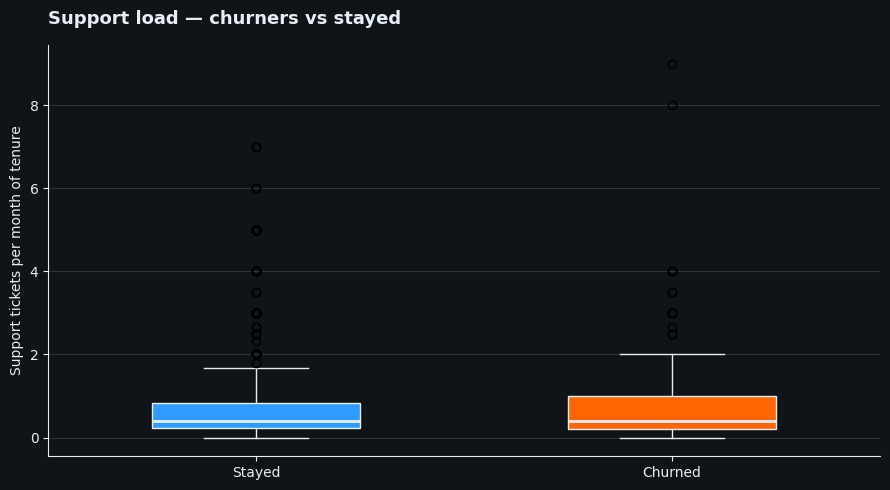

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
data = [per_acc.loc[~per_acc['churn_flag'], 'tickets_per_month'].dropna(),
        per_acc.loc[per_acc['churn_flag'], 'tickets_per_month'].dropna()]
bp = ax.boxplot(data, tick_labels=['Stayed', 'Churned'], patch_artist=True,
                widths=0.5, medianprops={'color': FG_LIGHT, 'linewidth': 2})
bp['boxes'][0].set_facecolor(BRAND_BLUE); bp['boxes'][0].set_edgecolor(FG_LIGHT)
bp['boxes'][1].set_facecolor(BRAND_ORANGE); bp['boxes'][1].set_edgecolor(FG_LIGHT)
for w in bp['whiskers'] + bp['caps']:
    w.set_color(FG_LIGHT)
ax.set_ylabel('Support tickets per month of tenure')
ax.set_title('Support load — churners vs stayed', loc='left', pad=15)
ax.grid(True, axis='y', alpha=0.15, color=FG_LIGHT)
plt.tight_layout(); plt.show()

**Read — a null result, and an important one:**

Stayers and churners file roughly the **same** number of tickets per month (~0.93 vs ~0.96). Their escalation rates, satisfaction scores, and resolution times are essentially identical. The boxplot distributions overlap almost completely.

If you were managing this business from a support dashboard, **you would have no early warning** from raw ticket metrics. That contradicts the common SaaS narrative that high support load equals churn risk.

## 3. The renewal-hump test — does the signal exist in the pre-renewal window?

The hypothesis is narrower than "support predicts churn in general." It says: *specifically in the months before the renewal decision, ticket activity should rise for customers who will churn at renewal.*

In [4]:
# Customers observable through the renewal window
eligible = per_acc[per_acc['observable_months'] >= 12].copy()
tk_window = tk[(tk['months_since_signup'] >= 9) & (tk['months_since_signup'] <= 12)]
prerenewal = tk_window.groupby('account_id').size().rename('tickets_9_12')
eligible = eligible.merge(prerenewal, on='account_id', how='left')
eligible['tickets_9_12'] = eligible['tickets_9_12'].fillna(0).astype(int)

# Did they churn during the renewal window (mo 13-18)?
eligible['renewal_churn'] = (
    eligible['churn_flag'] &
    (eligible['tenure_months'] >= 13) &
    (eligible['tenure_months'] <= 18)
)

def bucket(n):
    if n == 0: return '0 tickets'
    if n <= 2: return '1-2'
    if n <= 5: return '3-5'
    return '6+'

order = ['0 tickets', '1-2', '3-5', '6+']
eligible['bucket'] = eligible['tickets_9_12'].apply(bucket)
test = eligible.groupby('bucket').agg(
    n=('account_id', 'count'),
    renewal_churned=('renewal_churn', 'sum'),
).reindex(order).fillna(0).astype(int)
test['renewal_churn_rate'] = (test['renewal_churned'] / test['n'].replace(0, np.nan))
test

,n,renewal_churned,renewal_churn_rate
bucket,,,
0 tickets,131,11,0.083969
1-2,96,12,0.125000
3-5,3,1,0.333333
6+,0,0,NaN


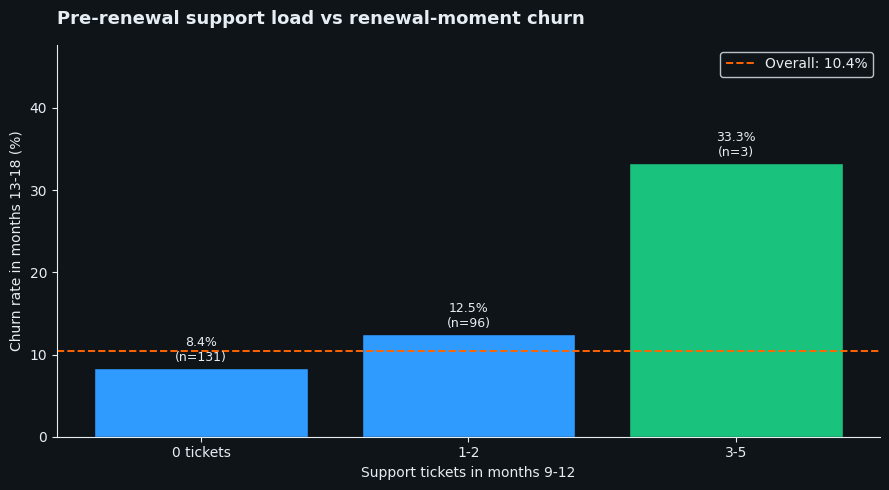

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
valid = test.dropna(subset=['renewal_churn_rate'])
colors_b = [BRAND_BLUE, BRAND_BLUE, BRAND_GREEN, BRAND_ORANGE][:len(valid)]
bars = ax.bar(valid.index, valid['renewal_churn_rate'] * 100, color=colors_b, edgecolor=BG_DARK)
overall_rr = eligible['renewal_churn'].mean()
ax.axhline(overall_rr * 100, color=BRAND_ORANGE, linestyle='--', linewidth=1.4,
           label=f'Overall: {overall_rr:.1%}')
for bar, rate, n in zip(bars, valid['renewal_churn_rate'], valid['n']):
    ax.text(bar.get_x() + bar.get_width()/2, rate * 100 + 0.5,
            f'{rate:.1%}\n(n={n})', ha='center', va='bottom', color=FG_LIGHT, fontsize=9)
ax.set_ylabel('Churn rate in months 13-18 (%)')
ax.set_xlabel('Support tickets in months 9-12')
ax.set_title('Pre-renewal support load vs renewal-moment churn', loc='left', pad=15)
ax.set_ylim(0, max(valid['renewal_churn_rate'] * 100) * 1.4 + 1)
ax.legend(facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT)
plt.tight_layout(); plt.show()

**Read — a real but narrow signal:**

- Customers with **0 tickets** in months 9-12 → 8.4% churn at renewal.
- Customers with **1-2 tickets** → 12.5%.
- Customers with **3+ tickets** → 33% — but **only 3 customers fell into this bucket**, so this is suggestive, not conclusive.

The hypothesis from notebook 2 is **partially supported**. There's a real dose-response relationship at the renewal moment, but the effect is modest and the high-ticket bucket is too thin to be definitive on its own. With more data, this is exactly the kind of signal you'd build a customer-success trigger around — but you'd want to validate it with another year's worth of cohort data first.

## 4. Sanity-check the obvious: do escalations or low satisfaction predict churn?

Most CRM dashboards highlight these metrics as risk indicators. Does the data agree?

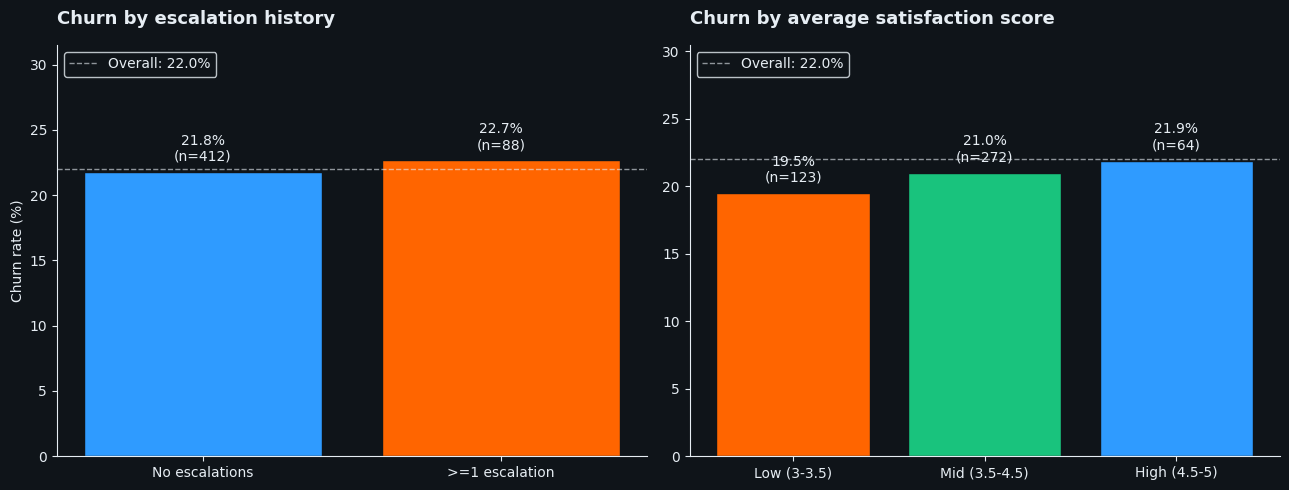

In [6]:
per_acc['had_escalation'] = per_acc['escalations'] > 0
esc = per_acc.groupby('had_escalation').agg(
    n=('account_id', 'count'),
    churn_rate=('churn_flag', 'mean'),
).round(3)
esc.index = ['No escalations', '>=1 escalation']

per_acc['sat_bucket'] = pd.cut(per_acc['avg_satisfaction'], bins=[0, 3.5, 4.5, 5.1],
                                labels=['Low (3-3.5)', 'Mid (3.5-4.5)', 'High (4.5-5)'])
sat = per_acc.dropna(subset=['sat_bucket']).groupby('sat_bucket', observed=True).agg(
    n=('account_id', 'count'),
    churn_rate=('churn_flag', 'mean'),
).round(3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax1, ax2 = axes
overall = per_acc['churn_flag'].mean()

b1 = ax1.bar(esc.index, esc['churn_rate'] * 100, color=[BRAND_BLUE, BRAND_ORANGE], edgecolor=BG_DARK)
ax1.axhline(overall * 100, color=FG_LIGHT, linestyle='--', linewidth=1, alpha=0.6,
            label=f'Overall: {overall:.1%}')
for bar, rate, n in zip(b1, esc['churn_rate'], esc['n']):
    ax1.text(bar.get_x() + bar.get_width()/2, rate * 100 + 0.6,
             f'{rate:.1%}\n(n={n})', ha='center', va='bottom', color=FG_LIGHT, fontsize=10)
ax1.set_ylabel('Churn rate (%)')
ax1.set_title('Churn by escalation history', loc='left', pad=15)
ax1.set_ylim(0, max(esc['churn_rate'] * 100) * 1.3 + 2)
ax1.legend(facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT, loc='upper left')

b2 = ax2.bar(sat.index.astype(str), sat['churn_rate'] * 100,
             color=[BRAND_ORANGE, BRAND_GREEN, BRAND_BLUE], edgecolor=BG_DARK)
ax2.axhline(overall * 100, color=FG_LIGHT, linestyle='--', linewidth=1, alpha=0.6,
            label=f'Overall: {overall:.1%}')
for bar, rate, n in zip(b2, sat['churn_rate'], sat['n']):
    ax2.text(bar.get_x() + bar.get_width()/2, rate * 100 + 0.6,
             f'{rate:.1%}\n(n={n})', ha='center', va='bottom', color=FG_LIGHT, fontsize=10)
ax2.set_title('Churn by average satisfaction score', loc='left', pad=15)
ax2.set_ylim(0, max(sat['churn_rate'] * 100) * 1.3 + 2)
ax2.legend(facecolor=BG_DARK, edgecolor=FG_LIGHT, labelcolor=FG_LIGHT, loc='upper left')
plt.tight_layout(); plt.show()

**Read — another null result, and an important one:**

- Customers with escalations churn at 22.7%; those without at 21.8%. **No meaningful difference.**
- Customers with the *lowest* satisfaction scores actually churn slightly less than those with the highest. The dashboard intuition is upside down here, and the spread is small enough that the right read is *no signal*.

Common CRM risk indicators — *had_escalation*, *low_csat* — are not predictive in this dataset. A retention program built on those triggers would chase the wrong customers.

---
## What this notebook concludes

I came in expecting support metrics to be a clean leading indicator. They are not.

1. **Raw ticket volume, escalations, and satisfaction scores do not separate stayers from churners.** The standard CRM risk dashboard would mislead an operator using this data.
2. **There *is* a narrow signal in the pre-renewal window:** customers who file 1+ tickets in months 9–12 churn at the renewal moment at roughly 1.5× the rate of customers who file zero. The signal is real but the sample at high ticket counts is too thin to act on alone.
3. **The "support" reason that renewal-stage churners cite in their exit feedback is therefore best read as a euphemism** — a polite way of saying *the year-two value proposition isn't holding up*, rather than a literal complaint about support quality.

## What this changes about the study's recommendation

- Don't build a churn early-warning system on ticket dashboards. It won't catch the cases that matter.
- *Do* trigger customer-success outreach at month 9 regardless of ticket activity. The data shows the renewal hump is largely independent of operational support signals.
- The real lever for renewal-stage churn is upstream: **plan structure, expansion paths, and contract design** — which is the subject of the next notebook on pricing strategy.